<a href="https://colab.research.google.com/github/bhausaheb-pachaptil/Basics-of-Python-/blob/main/AutoenocderCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
!pip install wfdb numpy matplotlib tensorflow

In [16]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt

# Download MIT-BIH sample (or skip if you uploaded your own file)
wfdb.dl_database('mitdb', records=['101'], dl_dir='.', overwrite=False)

# Read record
record = wfdb.rdrecord('100')

# Extract first channel
ecg_signal = record.p_signal[:, 0]

print("Total signal length:", len(ecg_signal))

Generating record list for: 101
Generating list of all files for: 101
Finished downloading files
Total signal length: 650000


In [17]:
# Take only small part (IMPORTANT)
ecg_small = ecg_signal[:2000]

print("Segment length:", len(ecg_small))

Segment length: 2000


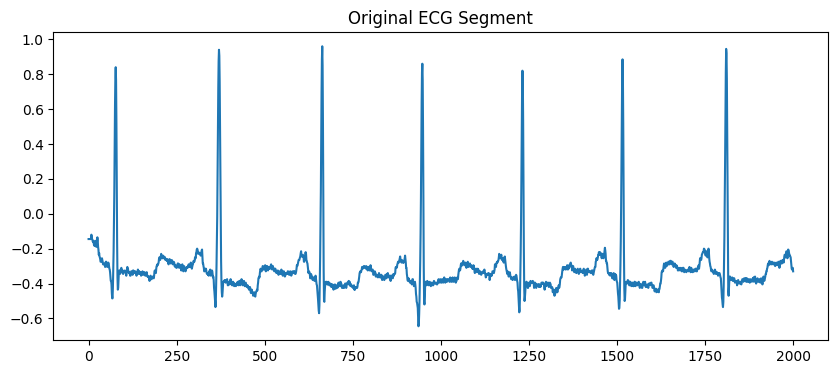

In [18]:
plt.figure(figsize=(10,4))
plt.plot(ecg_small)
plt.title("Original ECG Segment")
plt.show()

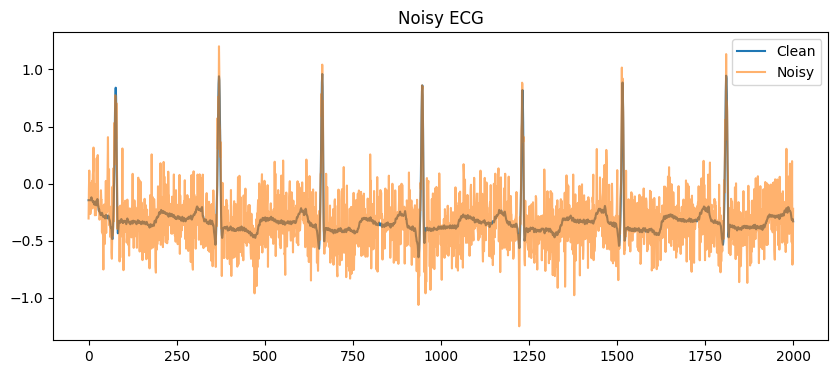

In [19]:
noise = 0.2 * np.random.normal(size=ecg_small.shape)
noisy_ecg = ecg_small + noise

plt.figure(figsize=(10,4))
plt.plot(ecg_small, label='Clean')
plt.plot(noisy_ecg, label='Noisy', alpha=0.6)
plt.legend()
plt.title("Noisy ECG")
plt.show()

In [20]:
ecg_small = (ecg_small - np.min(ecg_small)) / (np.max(ecg_small) - np.min(ecg_small))
noisy_ecg = (noisy_ecg - np.min(noisy_ecg)) / (np.max(noisy_ecg) - np.min(noisy_ecg))

In [21]:
def create_windows(signal, window_size=64):
    X = []
    for i in range(len(signal) - window_size):
        X.append(signal[i:i+window_size])
    return np.array(X)

window_size = 64

X_noisy = create_windows(noisy_ecg, window_size)
X_clean = create_windows(ecg_small, window_size)

print("Shape:", X_noisy.shape)

Shape: (1936, 64)


In [22]:
split = int(0.8 * len(X_noisy))

x_train = X_noisy[:split]
y_train = X_clean[:split]

x_test = X_noisy[split:]
y_test = X_clean[split:]

In [23]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, UpSampling1D
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input

# Reshape for CNN
x_train_cnn = x_train.reshape((x_train.shape[0], window_size, 1))
y_train_cnn = y_train.reshape((y_train.shape[0], window_size, 1))

x_test_cnn = x_test.reshape((x_test.shape[0], window_size, 1))
y_test_cnn = y_test.reshape((y_test.shape[0], window_size, 1))

# Input
input_layer = Input(shape=(window_size, 1))

# Encoder
x = Conv1D(32, 3, activation='relu', padding='same')(input_layer)
x = MaxPooling1D(2, padding='same')(x)

x = Conv1D(16, 3, activation='relu', padding='same')(x)
x = MaxPooling1D(2, padding='same')(x)

# Bottleneck
x = Conv1D(8, 3, activation='relu', padding='same')(x)

# Decoder
x = UpSampling1D(2)(x)
x = Conv1D(16, 3, activation='relu', padding='same')(x)

x = UpSampling1D(2)(x)
x = Conv1D(32, 3, activation='relu', padding='same')(x)

# Output
output_layer = Conv1D(1, 3, activation='sigmoid', padding='same')(x)

# Model
autoencoder = Model(input_layer, output_layer)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 64, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 32, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 32, 16)         │         1,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 16, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 16, 8)          │           392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_2 (UpSampling1D)  │ (None, 32, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 32, 16)         │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_3 (UpSampling1D)  │ (None, 64, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 64, 32)         │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 64, 1)          │            97 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,137 (16.16 KB)

 Trainable params: 4,137 (16.16 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
history = autoencoder.fit(
    x_train_cnn, y_train_cnn,
    epochs=30,
    batch_size=32,
    validation_data=(x_test_cnn, y_test_cnn)
)

Epoch 1/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - loss: 0.0336 - val_loss: 0.0127
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0149 - val_loss: 0.0105
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0105 - val_loss: 0.0059
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0060 - val_loss: 0.0045
Epoch 5/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0048 - val_loss: 0.0037
Epoch 6/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0035 - val_loss: 0.0024
Epoch 7/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0019 - val_loss: 0.0015
Epoch 8/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 9/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0011 - val_loss: 0.0012
Epoch 10/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0011 - val_loss: 0.0012
Epoch 11/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 9.7168e-04 - val_loss: 0.0011
Epoch 12/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9

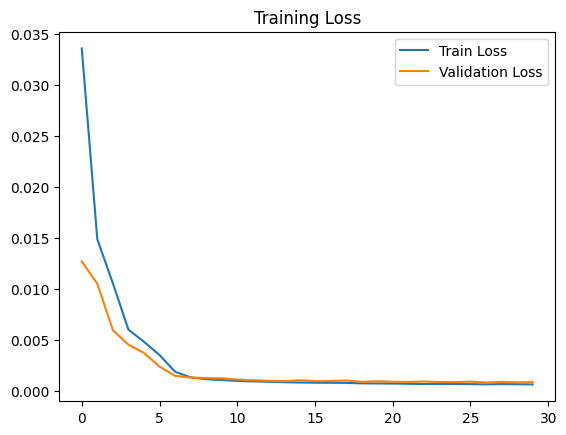

In [25]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training Loss")
plt.show()

In [26]:
denoised = autoencoder.predict(x_test_cnn)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step


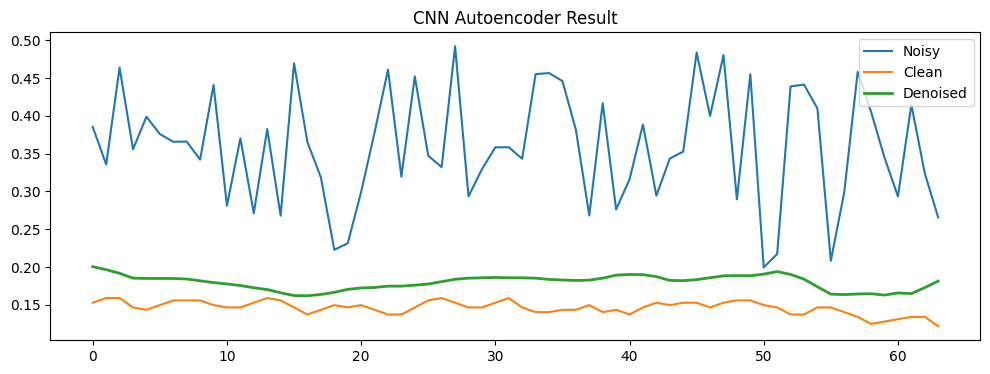

In [27]:
plt.figure(figsize=(12,4))

plt.plot(x_test_cnn[0].reshape(-1), label='Noisy')
plt.plot(y_test_cnn[0].reshape(-1), label='Clean')
plt.plot(denoised[0].reshape(-1), label='Denoised', linewidth=2)

plt.legend()
plt.title("CNN Autoencoder Result")
plt.show()

In [28]:
# Extract encoder (compressed features)
encoder = Model(inputs=input_layer, outputs=autoencoder.layers[4].output)

compressed = encoder.predict(x_test_cnn)

print("Compressed shape:", compressed.shape)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Compressed shape: (388, 16, 16)
